# Iterative sample-based

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from alg3 import EpsilonEstimate
from alg2 import mse, ModelOptReg
import covariance_matrices
from alg1 import GenXData, GenYData

In [6]:
rng = np.random.default_rng(seed=77)

EPSILON = 1
N_TRIAL = 100 # number of observations N
ASPECT_RATIO = 0.9 # aspect ratio (d/N)
D_TRIAL = int(ASPECT_RATIO * N_TRIAL) # number of parameters D

theta = rng.standard_normal(size=D_TRIAL)[:, np.newaxis]
theta = theta / np.linalg.norm(theta)

Sigma_spiked = covariance_matrices.spiked(D_TRIAL) # spiked covariance
X = GenXData(N_TRIAL, D_TRIAL, Sigma_spiked)
y = GenYData(X, N_TRIAL, theta, EPSILON)

LAMBDA_0 = 1
DELTA = 10 ** -4
P = 1 / 4

In [ ]:
def IterativeSampleOptReg(X, y, lambda_0, p, delta, theta_true, epsilon_true,
                           max_iter=100):
    """
    Runs the iterative sample-based optimal ridge regularization procedure
    for max_iter outer iterations (no early stopping), tracking lambda, mse, 
    and epsilon_hat at every step so convergence behavior can be inspected.

    If theta_true and epsilon_true are provided, also computes the oracle 
    lambda/mse (using ModelOptReg fed the true theta and epsilon) internally, 
    reusing the same S, V computed from X.

    Args:
        X: the design matrix with shape NxD.
        y: the truth vector with shape Nx1.
        lambda_0: the initial ridge regression parameter, often set to 1.
        p: the exponent parameter for the regularized rank, used in EpsilonEstimate.
        delta: the convergence tolerance on lambda, used for the inner (ModelOptReg) loop.
        theta_true: the true parameter vector, used to compute the oracle.
        epsilon_true: the true noise amplitude, used to compute the oracle.
        max_iter: number of outer iterations to run.
        verbose: if True, shows a tqdm progress bar over outer iterations.

    Returns:
        (lambda_star, mse_star): lambda and mse from the final iteration.
        (lambdas, mses, noises): lists tracking lambda, mse, and epsilon_hat 
            across every outer iteration, in order.
        (lambda_oracle, mse_oracle): the oracle lambda/mse if theta_true and 
            epsilon_true were provided, else (None, None).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=True)
    N, D = X.shape
    S = np.zeros((N, D))
    min_D_N = min(N, D)
    S[:min_D_N, :min_D_N] = np.diag(s[:min_D_N])
    V = Vt.T

    lam = lambda_0

    lambdas = []
    mses = []
    noises = []

    pbar = tqdm(range(max_iter), desc="IterativeSampleOptReg")
    for _ in pbar:
        theta_hat = V @ np.linalg.pinv(S + lam * np.eye(N, D)) @ U.T @ y
        epsilon_hat = EpsilonEstimate(X, U, S, V, y, p, lam)

        lam, mse_curr = ModelOptReg(S, V, theta_hat, epsilon_hat, lam, delta)

        lambdas.append(lam)
        mses.append(mse_curr)
        noises.append(epsilon_hat)

        pbar.set_postfix(lam=f"{lam:.6g}", mse=f"{mse_curr:.6g}", eps=f"{epsilon_hat:.6g}")

    pbar.close()

    lambda_oracle, mse_oracle = ModelOptReg(S, V, theta_true, epsilon_true, lambda_0, delta)

    return (lam, mses[-1]), (lambdas, mses, noises), (lambda_oracle, mse_oracle)

In [ ]:
(lam_star, mse_star), (lambdas, mses, noises), (lam_oracle, mse_oracle) = IterativeSampleOptReg(
    X, y, LAMBDA_0, P, DELTA, theta_true=theta, epsilon_true=EPSILON, max_iter=200
)

IterativeSampleOptReg:   0%|          | 0/200 [00:00<?, ?it/s, eps=0.984552, lam=40.0835, mse=1.33784]

IterativeSampleOptReg: 100%|██████████| 200/200 [00:02<00:00, 73.20it/s, eps=1.11752, lam=5.58067e+13, mse=1.24885]


In [18]:
print(f"Oracle:       lambda={lam_oracle:.6g}, mse={mse_oracle:.6g}")
print(f"Sample-based: lambda={lam_star:.6g}, mse={mse_star:.6g}  (after {len(mses)} iters)")

Oracle:       lambda=10000, mse=1
Sample-based: lambda=5.58067e+13, mse=1.24885  (after 200 iters)


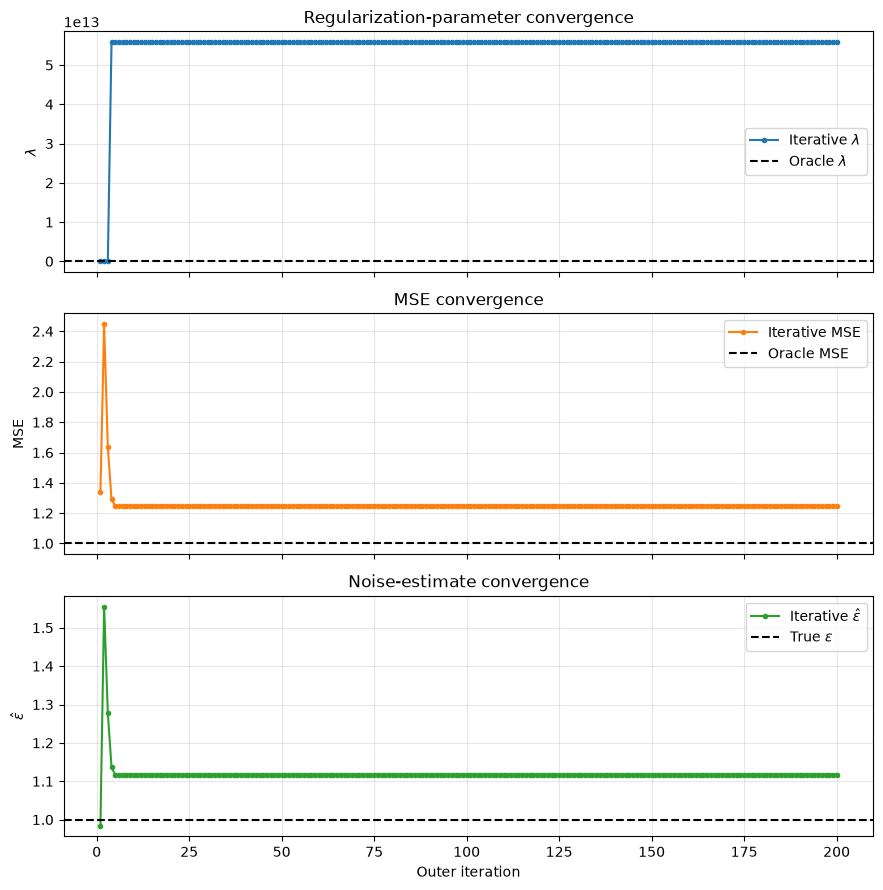

In [ ]:
iterations = np.arange(1, len(lambdas) + 1)
marker_size = 3

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Lambda
axes[0].plot(
    iterations, lambdas,
    marker="o", ms=marker_size,
    color="tab:blue",
    label=r"Iterative $\lambda$"
)
axes[0].axhline(
    lam_oracle,
    color="black", linestyle="--", linewidth=1.5,
    label=r"Oracle $\lambda$"
)
axes[0].set_ylabel(r"$\lambda$")
axes[0].set_title(r"Regularization-parameter convergence")
axes[0].grid(alpha=0.3)
axes[0].legend()

# MSE
axes[1].plot(
    iterations, mses,
    marker="o", ms=marker_size,
    color="tab:orange",
    label="Iterative MSE"
)
axes[1].axhline(
    mse_oracle,
    color="black", linestyle="--", linewidth=1.5,
    label="Oracle MSE"
)
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE convergence")
axes[1].grid(alpha=0.3)
axes[1].legend()

# Noise
axes[2].plot(
    iterations, noises,
    marker="o", ms=marker_size,
    color="tab:green",
    label=r"Iterative $\hat{\epsilon}$"
)
axes[2].axhline(
    EPSILON,
    color="black", linestyle="--", linewidth=1.5,
    label=r"True $\epsilon$"
)
axes[2].set_ylabel(r"$\hat{\epsilon}$")
axes[2].set_xlabel("Outer iteration")
axes[2].set_title(r"Noise-estimate convergence")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()